# Vectors and Matrices

In [1]:
# The standard stack:
import numpy as np # Linear algebra and random numbers
import matplotlib.pyplot as plt # Plotting
import pandas as pd # Data handling
import seaborn as sns # Statistical data visualization

 ## Introduction

 - A **vector** is an indexed list of $n$ numbers, on which we can do mathematical operations
 - We often represent phenomena as indexed lists of numbers:
   - Health outcomes for patients in a clinical trial
    - The sequence of values recorded for an experiment (a particle's position in space, gravity, the speed of light)
    - A sequence of stock prices
 - A **matrix** is a set of $\ell$ vectors of length $n$ stacked row-wise or column-wise
 - A **tensor** is a **multi-dimensional array** where you index slices of matrices

## Vectors
- In a dataframe, observations are rows and variables are columns: We need notation to track these concepts
- A $1\times m$ row vector is
$$
x = [x_1, x_2, x_3, ..., x_{m}]
$$
- An $n\times 1$ column vector is
$$
y = \left[ \begin{array}{c} y_1 \\ y_2 \\ \vdots \\ y_n \end{array} \right]
$$

In [2]:
df = pd.read_csv('./data/airbnb_clean.csv')
df[ ['review', 'Price']]

,review,Price
0,94.0,145
1,94.0,37
2,94.0,28
3,94.0,199
4,100.0,149
...,...,...
29683,94.0,300
29684,94.0,125
29685,94.0,80
29686,94.0,35


<Axes: xlabel='review', ylabel='Price'>

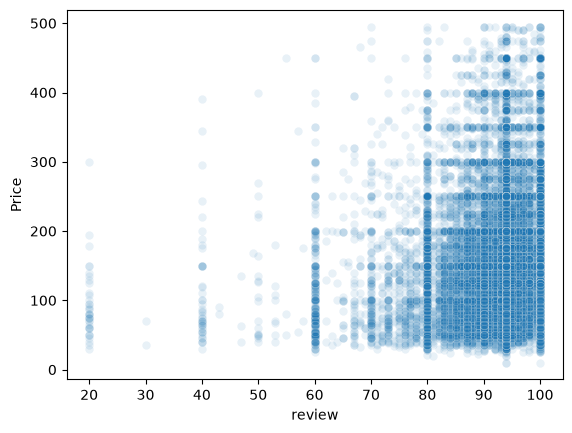

In [3]:
sns.scatterplot(data=df, x='review', y='Price', alpha =.1)

## Transpose
- When we take the **transpose** of a vector, we flip it from row to column:
$$
x^{\top} = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_{m} \end{array} \right]
\quad \text{ and } \quad
y^{\top} = [y_1, y_2, ..., y_{n}]
$$

## NumPy
- Vanilla Python doesn't have a vector class by default
- To extend Python to do vector operations, we use the `numpy` package, which provides standard linear algebra tools for data science and machine learning
- If you don't have numpy, you can `pip install numpy` and then `import numpy as np`
- To define a vector, use `x = np.array(vals)` where `vals` is any list of numeric values

In [4]:
x = [ 2, 3 , 4]
2 * x

import numpy as np

x = np.array([ 2, 3 , 4])
2*x

array([4, 6, 8])

## Indexing

- Most programming languages, including Python, however, start indexing from 0 and end at $m-1$ or $n-1$:
$$
x = [x_0, x_1, x_2, ..., x_{m-1}]
$$
and column vectors as 
$$
y = \left[ \begin{array}{c} y_0 \\ y_1 \\ \vdots \\ y_{n-1} \end{array} \right]
$$
- Indexing starts from 0: `x[0]` is the first value in `x`, `x[1]` is the second, and so on
- Notice that `range(n)` yields $0, 1, ..., n-1$

In [5]:
x = np.array([-1, 2, 3, 0])
print(f'The vector x: \n {x}')
print(f'x\'s shape: {x.shape}')

The vector x: 
 [-1  2  3  0]
x's shape: (4,)


## Example: Computing the Mean
- The **(sample) mean** of a vector $X$ is 
$$
m(X) = \frac{x_1 + x_2 + ... + x_n}{n} = \frac{1}{n} \sum_{i=1}^n x_i
$$
- Every summation $\sum_{i=1}^n$ is a loop in code, for index $i$ over `range(n)`. In a loop with vanilla Python, it's:
``` python
n = len(x)
sum = 0
for i in range(n):
    sum += x[i]
mean = sum/n
```
- To implement that in numpy, you can use `x.mean()`. 

## Vector Addition
- If we have two row or column vectors of the same length, we can add them together for **vector addition**, like so:
$$
x + y = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_n \end{array} \right] + \left[ \begin{array}{c} y_1 \\ y_2 \\ \vdots \\ y_n \end{array} \right] = \left[ \begin{array}{c} x_1 + y_1 \\ x_2 + y_2 \\ \vdots \\ x_n + y_n \end{array} \right]=z
$$

## Scalar Multiplication
- If we have a scalar $s$ like $5$ or $-3$, we can multiply it times each entry for **scalar multiplication**,
$$
sx = s\left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_n \end{array} \right] = \left[ \begin{array}{c} sx_1 \\ sx_2 \\ \vdots \\ sx_n \end{array} \right] 
$$
- Since normal addition and multiplication are associative and communitive, so are vector addition and scalar multiplication

In [6]:
x = np.array( [-1, 2, 3])
y = np.array( [-5, 7, 11])
z = x + y

## Combinations of Vectors
- If you combine scalar multiplication with scalars $r$ and $s$ and vector addition with vectors $x$ and $y$, you get a **linear combination**,
$$
sx + ry = \left[ \begin{array}{c} s x_1 + r y_1\\ s x_2 + r y_2\\ \vdots\\ s x_n + r y_n \end{array}  \right]
$$
- If the scalars on $x$ and $y$ are positive and sum to 1, you have a **convex combination**: Let $w$ be a number between 0 and 1, and
$$
wx + (1-w)y = \left[ \begin{array}{c} w x_1 + (1-w) y_1\\ w x_2 + (1-w) y_2\\ \vdots\\ w x_n + (1-w) y_n \end{array}  \right]
$$

## Example 1
- Take 
$$
x = \left[ \begin{array}{c} -2 \\ 3 \end{array} \right] \quad y = \left[ \begin{array}{c} 2 \\ 1 \end{array} \right]
$$
- Sketch the set of convex combinations of these vectors
- Sketch the set of all linear combinations of these vectors

## Example 2
- Take 
$$
x = \left[ \begin{array}{c} -1 \\ 2 \end{array} \right] \quad y = \left[ \begin{array}{c} 2 \\ -4 \end{array} \right]
$$
- Sketch the set of convex combinations of these vectors
- Sketch the set of all linear combinations of these vectors

## Example 3

Take the set of vectors
$$
x = \left[ \begin{array}{c} 1 \\ 0 \\ 0 \end{array} \right] \quad y = \left[ \begin{array}{c} 0 \\ 1 \\ 0  \end{array} \right] \quad z = \left[ \begin{array}{c} 0 \\ 0 \\ 1  \end{array} \right]
$$

- Sketch the sketch the set of linear combinations you can make with $x$ and $y$
- How does adding $z$ change the 
- What is the set of convex combinations of $x$ and $y$, $y$ and $z$, and $x$ and $z$? What about all three?

## Matrices
- If we stack
  - $n$ rows vectors $x^j$ of the same length $\ell$ on top of one another 
  - $\ell$ column vectors $y^j$ of the same length $n$ beside each other
- We get an $(n \times \ell)$ **matrix**, $A$:
$$
A = \left[ 
\begin{array}{c}
x^1 \\
x^2 \\
\vdots \\
x^n
\end{array}
\right] = \left[ \begin{array}{cccc} y^1 & y^2 & \dots & y^\ell \end{array} \right] = \left[ 
\begin{array}{c}
a_{11} & a_{12} & \dots & a_{1\ell}  \\
a_{21} & a_{22} & \dots & a_{2\ell}  \\
\vdots \\
a_{n1} & a_{n2} & \dots & a_{n\ell}  \\
\end{array}
\right]
$$
- This is just a mathematical concept that corresponds to "data frame"

## Matrix Addition, Hadamard Product
- When we add matrices, they have to have the same number of rows and columns, and we get:
$$
A + B = \left[ 
\begin{array}{c}
A_{11}+B_{11} & A_{12}+B_{12} & \dots & A_{1m}+B_{1m}  \\
A_{21}+B_{21} & A_{22}+B_{22} & \dots & A_{2m}+B_{2m}  \\
\vdots \\
A_{n1}+B_{n1} & A_{n2}+B_{n2} & \dots & A_{nm}+B_{nm}  \\
\end{array}
\right]
$$
- Matrix multiplication is **not** this:
$$
A \odot B = \left[ 
\begin{array}{c}
A_{11}*B_{11} & A_{12}*B_{12} & \dots & A_{1m}*B_{1m}  \\
A_{21}*B_{21} & A_{22}*B_{22} & \dots & A_{2m}*B_{2m}  \\
\vdots \\
A_{n1}*B_{n1} & A_{n2}*B_{n2} & \dots & A_{nm}*B_{nm}  \\
\end{array}
\right]
$$
This is called **elementwise multiplication** or the **Hadamard product**, but this **is** what you get with `A*B` with numpy.

## Reshaping
- Numpy pretends to think of all vectors as having a single dimension... and then sometimes demands you **reshape** them explicitly:
   - To row: `x[None,:]` or `x.reshape(1,-1)` for $(1 \times n)$
   - To column: `x[:,None]` or `x.reshape(-1,1)` for $( n \times 1)$


In [7]:
x = np.array([-1, 2, 3, 0])
print(f'The vector x: \n {x}')
print(f'x\'s shape: {x.shape}')

The vector x: 
 [-1  2  3  0]
x's shape: (4,)


In [8]:
x_row = x.reshape(1,-1)
print(f'x as a row vector:\n{x_row}')
print(f'x_row\'s shape: {x_row.shape}')
x_row = x[None,:]
print(f'x as a row vector:\n{x_row}')
print(f'x_row\'s shape: {x_row.shape}')

x as a row vector:
[[-1  2  3  0]]
x_row's shape: (1, 4)
x as a row vector:
[[-1  2  3  0]]
x_row's shape: (1, 4)


In [9]:
x_col = x.reshape(-1,1)
print(f'x as a column vector:\n{x_col}')
print(f'x_col\'s shape: {x_col.shape}')
x_col = x[:,None]
print(f'x as a column vector:\n{x_col}')
print(f'x_col\'s shape: {x_col.shape}')
print('\n')

x as a column vector:
[[-1]
 [ 2]
 [ 3]
 [ 0]]
x_col's shape: (4, 1)
x as a column vector:
[[-1]
 [ 2]
 [ 3]
 [ 0]]
x_col's shape: (4, 1)




## Broadcasting
- With Numpy, if you subtract a row and column vector of different dimension, it "guesses" what you meant, and **broadcasts** the calculation into a matrix
- This can often avoid double-for-loops, making it a really powerful tool for writing code
- For example, `x.reshape(1,-1) + y.reshape(-1,1)` or `x.reshape(1,-1) - y.reshape(-1,1)` yields:
$$
[x_1, x_2, ..., x_n] \oplus \left[\begin{array}{c} y_1 \\ y_2 \\ \vdots \\ y_m \end{array} \right] = \left[
\begin{array}{cccc}
x_1 \oplus y_1 & x_2 \oplus y_1 & \dots & x_n \oplus y_1 \\
x_1 \oplus y_2 & x_2 \oplus y_2 & \dots & x_n \oplus y_2 \\
\vdots & \vdots & \ddots & \vdots \\
x_1 \oplus y_m & x_2 \oplus y_m & \dots & x_n \oplus y_m 
\end{array}
 \right]
$$

In [10]:
x = np.array([-1, 2, 3, 0])
y = np.array([2,-3,11])
print(f'x: {x.reshape(1,-1)}')
print(f'y: {y.reshape(-1,1)}')

x: [[-1  2  3  0]]
y: [[ 2]
 [-3]
 [11]]


In [11]:
print('\n Subtraction:')
print( x.reshape(1,-1)-y.reshape(-1,1) )


 Subtraction:
[[ -3   0   1  -2]
 [  2   5   6   3]
 [-12  -9  -8 -11]]


In [12]:
print('\n Comparison:')
print( x.reshape(1,-1) <= y.reshape(-1,1) )


 Comparison:
[[ True  True False  True]
 [False False False False]
 [ True  True  True  True]]


In [13]:
print('\n Distance:')
print( np.sqrt( (x.reshape(1,-1) - y.reshape(-1,1)) **2 ) )


 Distance:
[[ 3.  0.  1.  2.]
 [ 2.  5.  6.  3.]
 [12.  9.  8. 11.]]
